# Statistical Analysis of Radioastron OJ287 Observations

## Imports

**Comment**: Below are provided imports.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

## Methods

**Comment**: Below are provided additional global methods to use in the Notebook.

In [30]:
def jd_from_datetime(dt):
    if pd.isna(dt):
        return np.nan
    year = dt.year
    month = dt.month
    day = dt.day
    hour = dt.hour + dt.minute/60.0 + dt.second/3600.0
    
    if month <= 2:
        year -= 1
        month += 12
    A = year // 100
    B = 2 - A + (A // 4)
    jd = int(365.25 * (year + 4716)) + int(30.6001 * (month + 1)) + day + B - 1524.5
    jd += hour / 24.0
    return jd

## Globals

**Comment**: Below are provided global variables.

In [31]:
# description of observational frequency bands
# P -- 316 MHz
# L -- 1668 MHz
# C -- 4828 MHz
# K -- 22236 MHz

bands = ['P', 'L', 'C', 'K']
bands_without_p = ['L', 'C', 'K']

# designation of colors for corresponding frequency bands
band_colors = {
    'P': "#DFDD83",
    'L': "#c3ff74",
    'C': "#a6f7e3",
    'K': "#86b9c9"
}

# designation of colors for corresponding correlation results
color_map = {
    0: '#3498db',   # синий     — только наземные
    1: '#2ecc71',   # зелёный   — УСПЕХ с Радиоастроном
    2: '#e74c3c',   # красный   — нет корреляции
    np.nan: '#95a5a6'  # серый — не наблюдался (x)
}

## Data Loading & Preparation

### Data Loading

**Comment**: Load table with observations.

In [32]:
df = pd.read_csv('Data_Table_18052026.txt', sep='\t')
flux = pd.read_csv('aavsodata_6a0c1ae1e02ce.txt', sep='\t')
ratan = pd.read_csv('RATAN-600_light_curves.txt', sep='\t')

**Comment**: Check head and tail of observations data table.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Obs. Code         92 non-null     object 
 1   Start date/time   92 non-null     object 
 2   Stop date/time    92 non-null     object 
 3   Telescopes        92 non-null     object 
 4   BL, (ED)          88 non-null     float64
 5   Bands             92 non-null     object 
 6   Tracking station  54 non-null     object 
 7   P                 92 non-null     object 
 8   L                 92 non-null     object 
 9   C                 92 non-null     object 
 10  K                 92 non-null     object 
dtypes: float64(1), object(10)
memory usage: 8.0+ KB


In [34]:
df.head()

,Obs. Code,Start date/time,Stop date/time,Telescopes,"BL, (ED)",Bands,Tracking station,P,L,C,K
0,raes03f,21.02.2012 1:30,21.02.2012 2:30,"GRT:Eb (C),Ys (C),Mc (L),Ev (L)",12.0,CL,NaN,x,0,1,x
1,raes03i,17.03.2012 15:00,17.03.2012 16:00,"GRT:Nt,Ev,Mc,Us",10.0,LC,NaN,x,2,0,x
2,raes03p,04.04.2012 18:30,04.04.2012 19:30,"GRT:Ef (C),Ys(C),Nt (C),Ev (L)",5.0,CL,NaN,x,1,1,x
3,raes03q,05.04.2012 17:00,05.04.2012 18:00,"GRT:Ef (C),Ys (C),Nt (C),Ev (L)",5.0,CL,NaN,x,1,1,x
4,raes03aa,27.04.2012 21:30,27.04.2012 23:30,GRT:Ar (C: 21:30-22:00; L: 22:05-22:30; P: 22:...,12.0,CLP,NaN,0,1,1,x


In [35]:
flux.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7523 entries, 0 to 7522
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   JD                    7523 non-null   float64
 1   Magnitude             7523 non-null   object 
 2   Uncertainty           6339 non-null   float64
 3   HQuncertainty         0 non-null      float64
 4   Band                  7521 non-null   object 
 5   Observer Code         7523 non-null   object 
 6   Comment Code(s)       160 non-null    object 
 7   Comp Star 1           4951 non-null   object 
 8   Comp Star 2           4163 non-null   object 
 9   Charts                7409 non-null   object 
 10  Comments              1667 non-null   object 
 11  Transfomed            6691 non-null   float64
 12  Airmass               5285 non-null   float64
 13  Validation Flag       7523 non-null   object 
 14  Cmag                  3859 non-null   float64
 15  Kmag                 

In [36]:
flux.head()

,JD,Magnitude,Uncertainty,HQuncertainty,Band,Observer Code,Comment Code(s),Comp Star 1,Comp Star 2,Charts,...,Cmag,Kmag,HJD,Star Name,Observer Affiliation,Measurement Method,Grouping Method,ADS Reference,Digitizer,Credit
0,2.455980e+06,15.406,0.02,NaN,V,GCO,NaN,ENSEMBLE,000-BBQ-007,1502KG,...,NaN,13.941,NaN,OJ 287,AAVSO,STD,NaN,NaN,NaN,NaN
1,2.455985e+06,15.1,0.20,NaN,V,HUR,NaN,150,NaN,JT060319,...,15.0,NaN,NaN,OJ 287,BAA-VSS,STD,NaN,NaN,NaN,NaN
2,2.455985e+06,15.08,NaN,NaN,V,PYG,NaN,S,NaN,251.02,...,14.6,NaN,NaN,OJ 287,NaN,STD,NaN,NaN,NaN,NaN
3,2.455985e+06,15.0,NaN,NaN,Vis.,STI,NaN,146,153,"6025en,ee",...,NaN,NaN,NaN,OJ 287,AAVSO,STD,NaN,NaN,NaN,NaN
4,2.455987e+06,15.0,NaN,NaN,Vis.,PYG,B,S-4,NaN,251.02,...,NaN,NaN,NaN,OJ 287,NaN,STD,NaN,NaN,NaN,NaN


In [37]:
ratan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           77 non-null     object
 1   21.7/22.3 GHz  77 non-null     object
 2   Unnamed: 2     77 non-null     object
 3   14.4 GHz       77 non-null     object
 4   Unnamed: 4     77 non-null     object
 5   11.2 GHz       77 non-null     object
 6   Unnamed: 6     77 non-null     object
 7   7.7/8.2 GHz    77 non-null     object
 8   Unnamed: 8     77 non-null     object
 9   4.8 GHz        77 non-null     object
 10  Unnamed: 10    77 non-null     object
 11  2.3 GHz        77 non-null     object
 12  Unnamed: 12    77 non-null     object
 13  1.1 GHz        77 non-null     object
 14  Unnamed: 14    77 non-null     object
dtypes: object(15)
memory usage: 9.2+ KB


In [38]:
ratan.head()

,Date,21.7/22.3 GHz,Unnamed: 2,14.4 GHz,Unnamed: 4,11.2 GHz,Unnamed: 6,7.7/8.2 GHz,Unnamed: 8,4.8 GHz,Unnamed: 10,2.3 GHz,Unnamed: 12,1.1 GHz,Unnamed: 14
0,15.04.2009,4.08,0.47,-,-,3.44,0.11,2.66,0.11,1.95,0.07,1.24,0.09,-,-
1,15.04.2011,7.82,0.87,-,-,6.85,0.24,5.64,0.11,4.5,0.09,-,-,-,-
2,15.07.2011,6.76,0.9,-,-,6.19,0.18,5.93,0.18,4.96,0.17,-,-,-,-
3,15.08.2011,4.38,0.44,-,-,5.21,0.16,5.44,0.22,4.85,0.15,-,-,-,-
4,15.09.2011,4.01,0.49,-,-,5.08,0.24,5.3,0.28,4.66,0.19,-,-,-,-


### Data Preparation

**Comment**: Prepare data and data-types.

In [39]:
for col in bands:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['BL'] = pd.to_numeric(df['BL, (ED)'], errors='coerce')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Obs. Code         92 non-null     object 
 1   Start date/time   92 non-null     object 
 2   Stop date/time    92 non-null     object 
 3   Telescopes        92 non-null     object 
 4   BL, (ED)          88 non-null     float64
 5   Bands             92 non-null     object 
 6   Tracking station  54 non-null     object 
 7   P                 3 non-null      float64
 8   L                 36 non-null     float64
 9   C                 76 non-null     float64
 10  K                 54 non-null     float64
 11  BL                88 non-null     float64
dtypes: float64(6), object(6)
memory usage: 8.8+ KB


In [41]:
df['Start'] = pd.to_datetime(df['Start date/time'], format='%d.%m.%Y %H:%M', errors='coerce')
df['Stop']  = pd.to_datetime(df['Stop date/time'],  format='%d.%m.%Y %H:%M', errors='coerce')
df['YearMonth'] = df['Start'].dt.to_period('M')


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Obs. Code         92 non-null     object        
 1   Start date/time   92 non-null     object        
 2   Stop date/time    92 non-null     object        
 3   Telescopes        92 non-null     object        
 4   BL, (ED)          88 non-null     float64       
 5   Bands             92 non-null     object        
 6   Tracking station  54 non-null     object        
 7   P                 3 non-null      float64       
 8   L                 36 non-null     float64       
 9   C                 76 non-null     float64       
 10  K                 54 non-null     float64       
 11  BL                88 non-null     float64       
 12  Start             92 non-null     datetime64[ns]
 13  Stop              92 non-null     datetime64[ns]
 14  YearMonth         92 non-nul

In [43]:
df['Start_JD'] = df['Start'].apply(jd_from_datetime)
df['Stop_JD']  = df['Stop'].apply(jd_from_datetime)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Obs. Code         92 non-null     object        
 1   Start date/time   92 non-null     object        
 2   Stop date/time    92 non-null     object        
 3   Telescopes        92 non-null     object        
 4   BL, (ED)          88 non-null     float64       
 5   Bands             92 non-null     object        
 6   Tracking station  54 non-null     object        
 7   P                 3 non-null      float64       
 8   L                 36 non-null     float64       
 9   C                 76 non-null     float64       
 10  K                 54 non-null     float64       
 11  BL                88 non-null     float64       
 12  Start             92 non-null     datetime64[ns]
 13  Stop              92 non-null     datetime64[ns]
 14  YearMonth         92 non-nul

In [45]:
flux['Magnitude'] = pd.to_numeric(flux['Magnitude'], errors='coerce')

In [46]:
new_names = {
    'Date': 'Date',
    '21.7/22.3 GHz': 'Flux_22',
    'Unnamed: 2': 'Flux_22e',      # ошибка / uncertainty
    '14.4 GHz': 'Flux_14',
    'Unnamed: 4': 'Flux_14e',
    '11.2 GHz': 'Flux_11',
    'Unnamed: 6': 'Flux_11e',
    '7.7/8.2 GHz': 'Flux_8',
    'Unnamed: 8': 'Flux_8e',
    '4.8 GHz': 'Flux_4',
    'Unnamed: 10': 'Flux_4e',
    '2.3 GHz': 'Flux_2',
    'Unnamed: 12': 'Flux_2e',
    '1.1 GHz': 'Flux_1',
    'Unnamed: 14': 'Flux_1e'
}

ratan = ratan.rename(columns=new_names)

flux_cols = ['Flux_22', 'Flux_22e', 'Flux_14', 'Flux_14e', 'Flux_11', 'Flux_11e',
             'Flux_8', 'Flux_8e', 'Flux_4', 'Flux_4e', 'Flux_2', 'Flux_2e', 
             'Flux_1', 'Flux_1e']

for col in flux_cols:
    ratan[col] = pd.to_numeric(ratan[col], errors='coerce')

print("Столбцы после переименования:")
print(ratan.columns.tolist())
print("\nПервые строки:")
print(ratan.head())

print("\nОсновная статистика по 22 ГГц:")
print(ratan[['Flux_22', 'Flux_22e']].describe())

Столбцы после переименования:
['Date', 'Flux_22', 'Flux_22e', 'Flux_14', 'Flux_14e', 'Flux_11', 'Flux_11e', 'Flux_8', 'Flux_8e', 'Flux_4', 'Flux_4e', 'Flux_2', 'Flux_2e', 'Flux_1', 'Flux_1e']

Первые строки:
         Date  Flux_22  Flux_22e  Flux_14  Flux_14e  Flux_11  Flux_11e  \
0  15.04.2009     4.08      0.47      NaN       NaN     3.44      0.11   
1  15.04.2011     7.82      0.87      NaN       NaN     6.85      0.24   
2  15.07.2011     6.76      0.90      NaN       NaN     6.19      0.18   
3  15.08.2011     4.38      0.44      NaN       NaN     5.21      0.16   
4  15.09.2011     4.01      0.49      NaN       NaN     5.08      0.24   

   Flux_8  Flux_8e  Flux_4  Flux_4e  Flux_2  Flux_2e  Flux_1  Flux_1e  
0    2.66     0.11    1.95     0.07    1.24     0.09     NaN      NaN  
1    5.64     0.11    4.50     0.09     NaN      NaN     NaN      NaN  
2    5.93     0.18    4.96     0.17     NaN      NaN     NaN      NaN  
3    5.44     0.22    4.85     0.15     NaN      NaN     Na

In [47]:
ratan['Date']  = pd.to_datetime(ratan['Date'],  format='%d.%m.%Y', errors='coerce')

In [48]:
ratan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      77 non-null     datetime64[ns]
 1   Flux_22   73 non-null     float64       
 2   Flux_22e  73 non-null     float64       
 3   Flux_14   1 non-null      float64       
 4   Flux_14e  1 non-null      float64       
 5   Flux_11   73 non-null     float64       
 6   Flux_11e  73 non-null     float64       
 7   Flux_8    34 non-null     float64       
 8   Flux_8e   34 non-null     float64       
 9   Flux_4    74 non-null     float64       
 10  Flux_4e   74 non-null     float64       
 11  Flux_2    15 non-null     float64       
 12  Flux_2e   15 non-null     float64       
 13  Flux_1    4 non-null      float64       
 14  Flux_1e   4 non-null      float64       
dtypes: datetime64[ns](1), float64(14)
memory usage: 9.2 KB


In [49]:
ratan['JD']  = ratan['Date'].apply(jd_from_datetime)

In [50]:
ratan.head()

,Date,Flux_22,Flux_22e,Flux_14,Flux_14e,Flux_11,Flux_11e,Flux_8,Flux_8e,Flux_4,Flux_4e,Flux_2,Flux_2e,Flux_1,Flux_1e,JD
0,2009-04-15,4.08,0.47,NaN,NaN,3.44,0.11,2.66,0.11,1.95,0.07,1.24,0.09,NaN,NaN,2454936.5
1,2011-04-15,7.82,0.87,NaN,NaN,6.85,0.24,5.64,0.11,4.50,0.09,NaN,NaN,NaN,NaN,2455666.5
2,2011-07-15,6.76,0.90,NaN,NaN,6.19,0.18,5.93,0.18,4.96,0.17,NaN,NaN,NaN,NaN,2455757.5
3,2011-08-15,4.38,0.44,NaN,NaN,5.21,0.16,5.44,0.22,4.85,0.15,NaN,NaN,NaN,NaN,2455788.5
4,2011-09-15,4.01,0.49,NaN,NaN,5.08,0.24,5.30,0.28,4.66,0.19,NaN,NaN,NaN,NaN,2455819.5


## Observations Statistical Analysis

### Distribution of Positive Space-Ground Detections vs. Baseline Projection

**Comments**: Plot distribution for each band with positive space-ground detections vs. baseline projection.

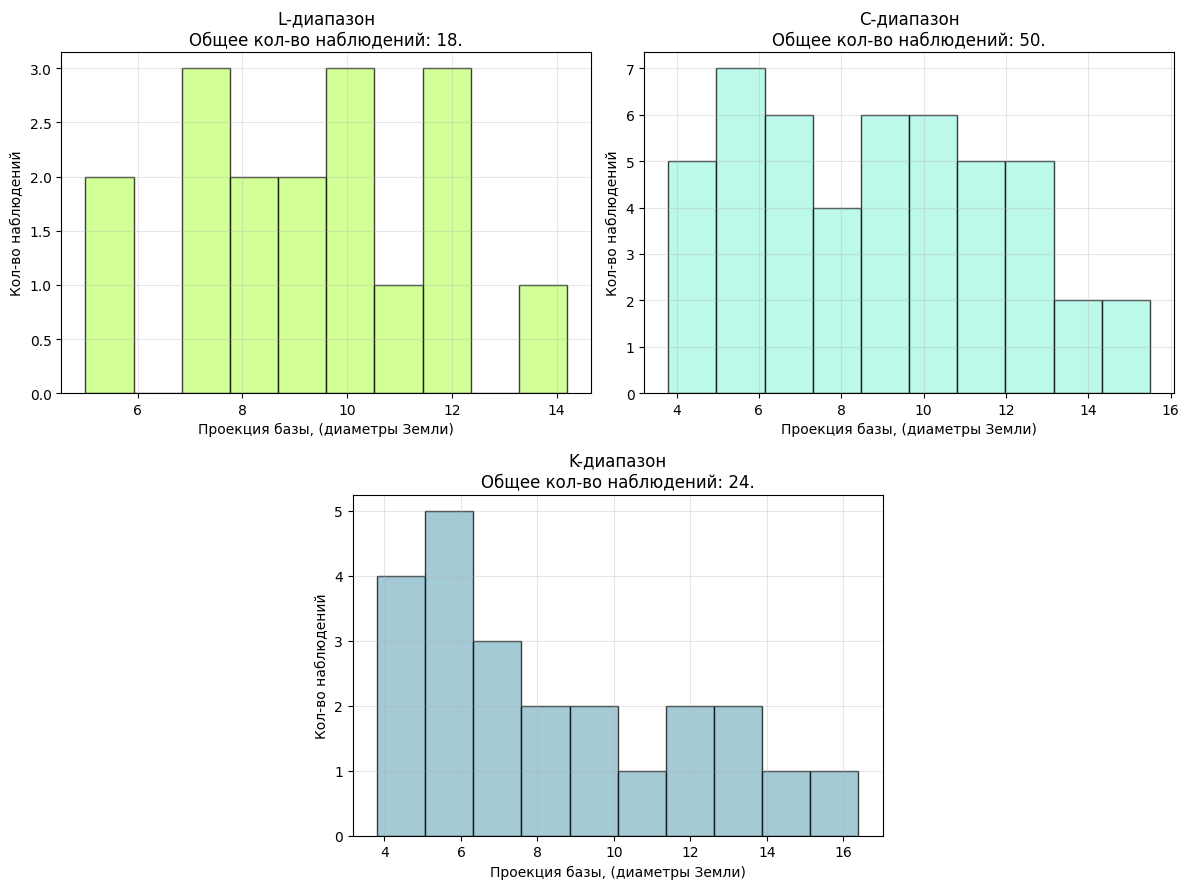

In [63]:
fig = plt.figure(figsize=(12, 9))

gs = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])

axes = [ax1, ax2, ax3]

for i in range(3):
    band = bands_without_p[i]
    ax = axes[i]
    data = df[df[band] == 1]

    if len(data) > 1:
        color = band_colors.get(band, 'steelblue')
        ax.hist(data['BL'], bins=10, alpha=0.75,
                color=color, edgecolor='black')
        ax.set_title(f'{band}-диапазон\nОбщее кол-во наблюдений: {len(data)}.')
        ax.set_xlabel('Проекция базы, (диаметры Земли)')
        ax.set_ylabel('Кол-во наблюдений')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data.', ha='center', va='center')

plt.tight_layout()
plt.show()

### Descriptive Statistics per Frequency Band

In [65]:
results = []

for band in bands:
    if band not in df.columns:
        continue
    total = len(df)
    valid = df[band].notna().sum()
    n0 = (df[band] == 0).sum()
    n1 = (df[band] == 1).sum()
    n2 = (df[band] == 2).sum()
    
    results.append({
        'Band': band,
        'Observed': valid,
        '0 (no correlation)': n0,
        '1 (space-ground)': n1,
        '2 (ground only)': n2
    })

stats_df = pd.DataFrame(results)
print("Correlation statistics per band:")
print(f"Total observations: {total}")
print(stats_df.round(1).to_string(index=False))

Correlation statistics per band:
Total observations: 92
Band  Observed  0 (no correlation)  1 (space-ground)  2 (ground only)
   P         3                   1                 1                1
   L        36                  11                18                7
   C        76                   6                50               20
   K        54                   8                24               22


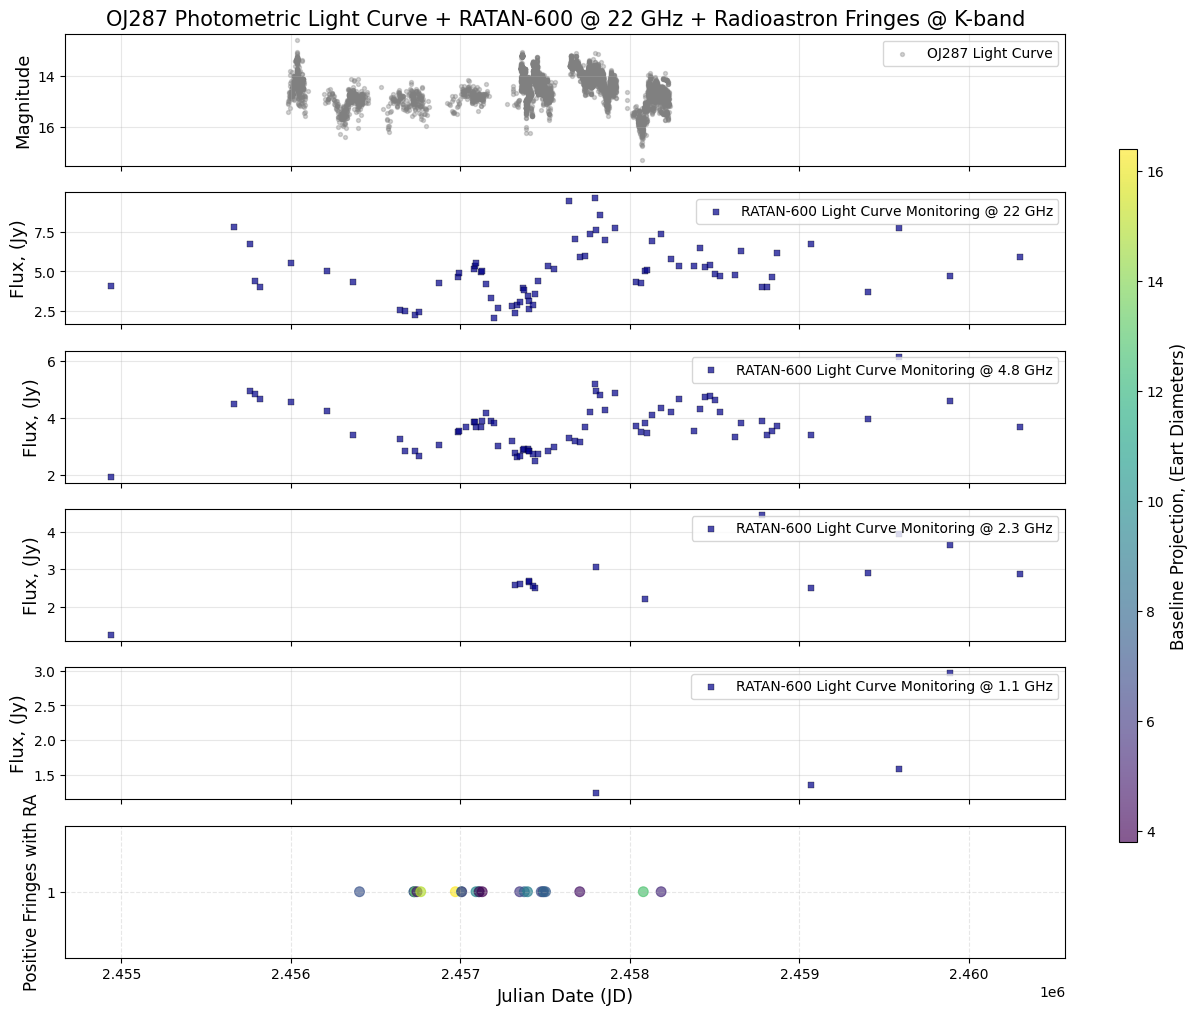

In [ ]:
fig, (ax0, ax1, ax2, ax3, ax4, ax5) = plt.subplots(6, 1, figsize=(16, 12), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1, 1, 1, 1, 1]})

ax0.scatter(flux['JD'], flux['Magnitude'], 
            s=8, alpha=0.35, color='gray', 
            label='OJ287 Light Curve', zorder=1)

ax0.set_ylabel('Magnitude', fontsize=13)
ax0.invert_yaxis()
ax0.grid(True, alpha=0.3)
ax0.set_title('OJ287 Photometric Light Curve + RATAN-600 @ 22 GHz + Radioastron Fringes @ K-band', fontsize=15)
ax0.legend(loc='upper right')

ax1.scatter(ratan['JD'], ratan['Flux_22'], 
            s=15, alpha=0.7, color='darkblue', 
            marker='s', edgecolors='black', linewidth=0.3,
            label='RATAN-600 Light Curve Monitoring @ 22 GHz', zorder=2)
ax1.set_ylabel('Flux, (Jy)', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

ax2.scatter(ratan['JD'], ratan['Flux_4'], 
            s=15, alpha=0.7, color='darkblue', 
            marker='s', edgecolors='black', linewidth=0.3,
            label='RATAN-600 Light Curve Monitoring @ 4.8 GHz', zorder=2)
ax2.set_ylabel('Flux, (Jy)', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

ax3.scatter(ratan['JD'], ratan['Flux_2'], 
            s=15, alpha=0.7, color='darkblue', 
            marker='s', edgecolors='black', linewidth=0.3,
            label='RATAN-600 Light Curve Monitoring @ 2.3 GHz', zorder=2)
ax3.set_ylabel('Flux, (Jy)', fontsize=13)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper right')

ax4.scatter(ratan['JD'], ratan['Flux_1'], 
            s=15, alpha=0.7, color='darkblue', 
            marker='s', edgecolors='black', linewidth=0.3,
            label='RATAN-600 Light Curve Monitoring @ 1.1 GHz', zorder=2)
ax4.set_ylabel('Flux, (Jy)', fontsize=13)
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper right')

k_success = df[df['K'] == 1].copy()

if len(k_success) > 0:
    k_success['BL'] = pd.to_numeric(k_success['BL, (ED)'], errors='coerce')
    
    scatter = ax5.scatter(k_success['Start_JD'], 
                          [1.0] * len(k_success),
                          c=k_success['BL'], 
                          s=50, 
                          cmap='viridis',
                          alpha=0.65, 
                          linewidth=0.8,
                          marker='o')
    
    cbar = fig.colorbar(scatter, ax=[ax0, ax1, ax2, ax3, ax4, ax5], pad=0.02, aspect=40, shrink=0.75)
    cbar.set_label('Baseline Projection, (Eart Diameters)', fontsize=12)
    
    ax5.set_ylabel('Positive Fringes with RA', fontsize=12)
    ax5.set_yticks([1.0])

else:
    ax5.text(0.5, 0.5, "No fringes found in K-band", 
             ha='center', va='center', transform=ax5.transAxes, fontsize=14)

ax5.grid(True, alpha=0.3, linestyle='--')

plt.xlabel('Julian Date (JD)', fontsize=13)
ax5.tick_params(axis='x', labelbottom=True)

plt.subplots_adjust(right=0.75)
plt.show()

# Angular Size and Brightness Temperature

Add here statistical analysis of obtained angular size

Add here estimations of brightness temperature

Add here comparison of brightness temperature vs. light curves at different bands (RATAN, photometry, X-ray, gamma-ray, etc.)